# Trader Performance vs Market Sentiment

End-to-end notebook:

1. Load both datasets
2. Clean + align by date
3. Build key metrics
4. Analyze Fear vs Greed behavior and performance
5. Visualize trends/patterns
6. Output actionable strategy ideas

Run cells from top to bottom.


In [27]:
# Dependency check (run this first)
import importlib.util

required_modules = ['pandas', 'numpy', 'matplotlib']
optional_modules = {'scikit-learn': 'sklearn', 'streamlit': 'streamlit'}

missing_required = [m for m in required_modules if importlib.util.find_spec(m) is None]
missing_optional = [name for name, mod in optional_modules.items() if importlib.util.find_spec(mod) is None]

if missing_required:
    raise RuntimeError(
        'Missing required packages: ' + ', '.join(missing_required) + '. '
        + 'Install in your notebook kernel, then rerun. Example: pip install pandas numpy matplotlib'
    )

if missing_optional:
    print('Optional packages missing:', ', '.join(missing_optional))
    print('For advanced modeling/dashboard, install: pip install scikit-learn streamlit')
else:
    print('All optional packages are available.')

print('All required packages are available.')

Optional packages missing: scikit-learn, streamlit
For advanced modeling/dashboard, install: pip install scikit-learn streamlit
All required packages are available.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from decimal import Decimal, InvalidOperation
from pathlib import Path
from IPython.display import display
import warnings

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

BASE_DIR = Path.cwd()
FG_PATH = BASE_DIR / 'fear_greed_index.csv'
HIST_PATH = BASE_DIR / 'historical_data.csv'

print('Working directory:', BASE_DIR)
print('Fear/Greed file exists:', FG_PATH.exists())
print('Historical file exists:', HIST_PATH.exists())

Working directory: /home/msh/Documents/primetrade
Fear/Greed file exists: True
Historical file exists: True


## Part A - Data Preparation


In [29]:
# Load raw data
fg_raw = pd.read_csv(FG_PATH)
hist_raw = pd.read_csv(
    HIST_PATH,
    dtype={'Trade ID': 'string', 'Timestamp': 'string', 'Order ID': 'string'}
)

print('Fear/Greed shape:', fg_raw.shape)
print('Historical shape:', hist_raw.shape)

display(fg_raw.head(3))
display(hist_raw.head(3))

Fear/Greed shape: (2644, 4)
Historical shape: (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.95E+14,1.73E+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.43E+14,1.73E+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.60E+14,1.73E+12


In [30]:
# Data quality report (rows, cols, missing, duplicates)
def quality_report(df, name):
    return pd.DataFrame([
        {
            'dataset': name,
            'rows': len(df),
            'columns': df.shape[1],
            'missing_cells': int(df.isna().sum().sum()),
            'duplicate_rows': int(df.duplicated().sum()),
        }
    ])

report = pd.concat(
    [quality_report(fg_raw, 'fear_greed_index.csv'), quality_report(hist_raw, 'historical_data.csv')],
    ignore_index=True,
)
print('Quality summary')
display(report)

print('Top missing columns in fear_greed_index.csv')
display(fg_raw.isna().sum().sort_values(ascending=False).head(10).to_frame('missing_count'))

print('Top missing columns in historical_data.csv')
display(hist_raw.isna().sum().sort_values(ascending=False).head(10).to_frame('missing_count'))

Quality summary


,dataset,rows,columns,missing_cells,duplicate_rows
0,fear_greed_index.csv,2644,4,0,0
1,historical_data.csv,211224,16,0,0


Top missing columns in fear_greed_index.csv


,missing_count
timestamp,0
value,0
classification,0
date,0


Top missing columns in historical_data.csv


,missing_count
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [31]:
# Clean Fear/Greed dataset
fg = fg_raw.rename(columns={
    'timestamp': 'fg_timestamp',
    'value': 'fg_value',
    'classification': 'fg_classification',
    'date': 'fg_date',
})

fg['fg_timestamp'] = pd.to_numeric(fg['fg_timestamp'], errors='coerce').astype('Int64')
fg['fg_value'] = pd.to_numeric(fg['fg_value'], errors='coerce')
fg['fg_classification'] = fg['fg_classification'].astype(str).str.strip().str.title()
fg['fg_date'] = pd.to_datetime(fg['fg_date'], errors='coerce').dt.normalize()

fg_clean = (
    fg.dropna(subset=['fg_date', 'fg_value'])
      .drop_duplicates(subset=['fg_date'], keep='last')
      .sort_values('fg_date')
      .reset_index(drop=True)
)
fg_clean['fg_value'] = fg_clean['fg_value'].astype(int)

print('Clean fear/greed shape:', fg_clean.shape)
display(fg_clean.head())

Clean fear/greed shape: (2644, 4)


,fg_timestamp,fg_value,fg_classification,fg_date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [32]:
# Clean historical dataset
def sci_to_int_string(value):
    if pd.isna(value):
        return pd.NA
    txt = str(value).strip()
    if not txt:
        return pd.NA
    try:
        return str(int(Decimal(txt)))
    except (InvalidOperation, OverflowError, ValueError):
        return pd.NA

hist = hist_raw.rename(columns={
    'Account': 'account',
    'Coin': 'coin',
    'Execution Price': 'execution_price',
    'Size Tokens': 'size_tokens',
    'Size USD': 'size_usd',
    'Side': 'side',
    'Timestamp IST': 'timestamp_ist',
    'Start Position': 'start_position',
    'Direction': 'direction',
    'Closed PnL': 'closed_pnl',
    'Transaction Hash': 'transaction_hash',
    'Order ID': 'order_id',
    'Crossed': 'crossed',
    'Fee': 'fee',
    'Trade ID': 'trade_id_raw',
    'Timestamp': 'timestamp_raw',
})

for col in ['account', 'coin', 'side', 'direction', 'transaction_hash', 'order_id']:
    hist[col] = hist[col].astype(str).str.strip()

hist['coin'] = hist['coin'].str.upper()
hist['side'] = hist['side'].str.upper()
hist['direction'] = hist['direction'].str.title()

for col in ['execution_price', 'size_tokens', 'size_usd', 'start_position', 'closed_pnl', 'fee']:
    hist[col] = pd.to_numeric(hist[col], errors='coerce')

hist['timestamp_ist'] = pd.to_datetime(hist['timestamp_ist'], format='%d-%m-%Y %H:%M', errors='coerce')
hist['timestamp_utc'] = (
    hist['timestamp_ist']
    .dt.tz_localize('Asia/Kolkata', ambiguous='NaT', nonexistent='NaT')
    .dt.tz_convert('UTC')
)
hist['trade_date'] = hist['timestamp_ist'].dt.normalize()

hist['trade_id'] = hist['trade_id_raw'].map(sci_to_int_string).astype('string')
hist['timestamp_ms_approx'] = hist['timestamp_raw'].map(sci_to_int_string).astype('string')

ts_num = pd.to_numeric(hist['timestamp_ms_approx'], errors='coerce')
hist['timestamp_approx_utc'] = pd.to_datetime(ts_num, unit='ms', utc=True, errors='coerce')
hist['timestamp_approx_ist'] = hist['timestamp_approx_utc'].dt.tz_convert('Asia/Kolkata')
hist['timestamp_approx_day_match'] = (
    hist['timestamp_approx_ist'].dt.tz_localize(None).dt.normalize() == hist['trade_date']
)

hist['is_long'] = hist['direction'].str.contains('Long', case=False, na=False)
hist['is_short'] = hist['direction'].str.contains('Short', case=False, na=False)
hist['is_win'] = hist['closed_pnl'] > 0
hist['is_loss'] = hist['closed_pnl'] < 0
hist['pnl_nonzero'] = hist['closed_pnl'] != 0

hist_clean = hist.dropna(subset=['timestamp_ist']).reset_index(drop=True)

print('Clean historical shape:', hist_clean.shape)
print('timestamp_raw unique values:', hist_clean['timestamp_raw'].nunique(dropna=True))
print('timestamp day match ratio:', round(hist_clean['timestamp_approx_day_match'].mean(), 4))
display(hist_clean.head())

Clean historical shape: (211224, 28)
timestamp_raw unique values: 7
timestamp day match ratio: 0.0102


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id_raw,timestamp_raw,timestamp_utc,trade_date,trade_id,timestamp_ms_approx,timestamp_approx_utc,timestamp_approx_ist,timestamp_approx_day_match,is_long,is_short,is_win,is_loss,pnl_nonzero
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.95E+14,1.73E+12,2024-12-02 17:20:00+00:00,2024-12-02,895000000000000,1730000000000,2024-10-27 03:33:20+00:00,2024-10-27 09:03:20+05:30,False,False,False,False,False,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.43E+14,1.73E+12,2024-12-02 17:20:00+00:00,2024-12-02,443000000000000,1730000000000,2024-10-27 03:33:20+00:00,2024-10-27 09:03:20+05:30,False,False,False,False,False,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.60E+14,1.73E+12,2024-12-02 17:20:00+00:00,2024-12-02,660000000000000,1730000000000,2024-10-27 03:33:20+00:00,2024-10-27 09:03:20+05:30,False,False,False,False,False,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.08E+15,1.73E+12,2024-12-02 17:20:00+00:00,2024-12-02,1080000000000000,1730000000000,2024-10-27 03:33:20+00:00,2024-10-27 09:03:20+05:30,False,False,False,False,False,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.05E+15,1.73E+12,2024-12-02 17:20:00+00:00,2024-12-02,1050000000000000,1730000000000,2024-10-27 03:33:20+00:00,2024-10-27 09:03:20+05:30,False,False,False,False,False,False


In [33]:
# Align datasets by date
merged = hist_clean.merge(
    fg_clean[['fg_date', 'fg_value', 'fg_classification']],
    left_on='trade_date',
    right_on='fg_date',
    how='left'
)

matched = merged['fg_value'].notna().sum()
coverage = merged['fg_value'].notna().mean()

print('Rows matched with sentiment:', matched, '/', len(merged))
print('Coverage ratio:', round(coverage, 4))

# Create sentiment bucket for grouped analysis

def sentiment_bucket(x):
    s = str(x).lower()
    if 'fear' in s:
        return 'Fear'
    if 'greed' in s:
        return 'Greed'
    if 'neutral' in s:
        return 'Neutral'
    return 'Unknown'

merged['sentiment_bucket'] = merged['fg_classification'].map(sentiment_bucket)

display(merged[['trade_date', 'account', 'coin', 'closed_pnl', 'sentiment_bucket']].head())

Rows matched with sentiment: 211218 / 211224
Coverage ratio: 1.0


,trade_date,account,coin,closed_pnl,sentiment_bucket
0,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Greed
1,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Greed
2,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Greed
3,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Greed
4,2024-12-02,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Greed


In [34]:
# Build key metrics
account_daily = (
    merged.groupby(['trade_date', 'account', 'sentiment_bucket', 'fg_classification'], as_index=False)
    .agg(
        trades=('account', 'size'),
        total_pnl=('closed_pnl', 'sum'),
        avg_trade_size_usd=('size_usd', 'mean'),
        total_volume_usd=('size_usd', 'sum'),
        wins=('is_win', 'sum'),
        losses=('is_loss', 'sum'),
        pnl_nonzero_count=('pnl_nonzero', 'sum'),
        long_trades=('is_long', 'sum'),
        short_trades=('is_short', 'sum'),
        avg_fee=('fee', 'mean'),
    )
)

account_daily['win_rate'] = np.where(
    account_daily['pnl_nonzero_count'] > 0,
    account_daily['wins'] / account_daily['pnl_nonzero_count'],
    np.nan,
)
account_daily['long_short_ratio'] = np.where(
    account_daily['short_trades'] > 0,
    account_daily['long_trades'] / account_daily['short_trades'],
    np.nan,
)

account_daily = account_daily.sort_values(['account', 'trade_date']).reset_index(drop=True)
account_daily['cum_pnl'] = account_daily.groupby('account')['total_pnl'].cumsum()
account_daily['cum_peak'] = account_daily.groupby('account')['cum_pnl'].cummax()
account_daily['drawdown_proxy'] = account_daily['cum_pnl'] - account_daily['cum_peak']

daily_market = (
    merged.groupby(['trade_date', 'sentiment_bucket'], as_index=False)
    .agg(
        trades=('account', 'size'),
        unique_accounts=('account', 'nunique'),
        total_volume_usd=('size_usd', 'sum'),
        total_pnl=('closed_pnl', 'sum'),
        avg_trade_size_usd=('size_usd', 'mean'),
        long_ratio=('is_long', 'mean'),
        short_ratio=('is_short', 'mean'),
    )
)

coin_summary = (
    merged.groupby('coin', as_index=False)
    .agg(
        trades=('coin', 'size'),
        total_volume_usd=('size_usd', 'sum'),
        total_closed_pnl=('closed_pnl', 'sum'),
        mean_trade_usd=('size_usd', 'mean'),
    )
    .sort_values('total_volume_usd', ascending=False)
)

class_summary = (
    merged.dropna(subset=['fg_classification'])
    .groupby('fg_classification', as_index=False)
    .agg(
        trades=('coin', 'size'),
        avg_trade_usd=('size_usd', 'mean'),
        total_volume_usd=('size_usd', 'sum'),
        total_closed_pnl=('closed_pnl', 'sum'),
        avg_fee=('fee', 'mean'),
        buy_ratio=('side', lambda s: (s == 'BUY').mean()),
    )
    .sort_values('trades', ascending=False)
)

daily_metrics = (
    merged.groupby('trade_date', as_index=False)
    .agg(
        trades=('coin', 'size'),
        total_volume_usd=('size_usd', 'sum'),
        total_closed_pnl=('closed_pnl', 'sum'),
        nonzero_closed_pnl=('closed_pnl', lambda s: s[s != 0].sum()),
        buy_ratio=('side', lambda s: (s == 'BUY').mean()),
        fg_value=('fg_value', 'mean'),
    )
    .sort_values('trade_date')
)

print('account_daily:', account_daily.shape)
print('daily_market:', daily_market.shape)
print('coin_summary:', coin_summary.shape)
print('class_summary:', class_summary.shape)
print('daily_metrics:', daily_metrics.shape)
display(account_daily.head())

account_daily: (2340, 19)
daily_market: (480, 9)
coin_summary: (246, 5)
class_summary: (5, 7)
daily_metrics: (480, 7)


,trade_date,account,sentiment_bucket,fg_classification,trades,total_pnl,avg_trade_size_usd,total_volume_usd,wins,losses,pnl_nonzero_count,long_trades,short_trades,avg_fee,win_rate,long_short_ratio,cum_pnl,cum_peak,drawdown_proxy
0,2024-11-11,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,Extreme Greed,177,0.0,5089.718249,900880.13,0,0,0,0,177,0.948000,NaN,0.0,0.0,0.0,0.0
1,2024-11-17,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,Extreme Greed,68,0.0,7976.664412,542413.18,0,0,0,0,68,0.998288,NaN,0.0,0.0,0.0,0.0
2,2024-11-18,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,Extreme Greed,40,0.0,23734.500000,949380.00,0,0,0,0,40,2.373450,NaN,0.0,0.0,0.0,0.0
3,2024-11-22,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,Extreme Greed,12,-21227.0,28186.666667,338240.00,0,12,12,0,12,2.818666,0.0,0.0,-21227.0,0.0,-21227.0
4,2024-11-26,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,Extreme Greed,27,1603.1,17248.148148,465700.00,12,0,12,0,27,3.874907,1.0,0.0,-19623.9,0.0,-19623.9


In [35]:
# Save key output files
fg_clean.to_csv('fear_greed_index_clean.csv', index=False)
hist_clean.to_csv('historical_data_clean.csv', index=False)
account_daily.to_csv('account_daily_metrics.csv', index=False)
daily_market.to_csv('daily_market_metrics.csv', index=False)
coin_summary.to_csv('coin_summary.csv', index=False)
class_summary.to_csv('fear_greed_class_summary.csv', index=False)
daily_metrics.to_csv('daily_trade_metrics.csv', index=False)

print('Saved output files successfully.')

Saved output files successfully.


## Part B - Analysis


In [36]:
# B1) Performance differences: Fear vs Greed
perf_fg = (
    account_daily[account_daily['sentiment_bucket'].isin(['Fear', 'Greed'])]
    .groupby('sentiment_bucket', as_index=False)
    .agg(
        trader_days=('account', 'size'),
        mean_daily_pnl=('total_pnl', 'mean'),
        median_daily_pnl=('total_pnl', 'median'),
        mean_win_rate=('win_rate', 'mean'),
        median_drawdown_proxy=('drawdown_proxy', 'median'),
        mean_trade_count=('trades', 'mean'),
        mean_trade_size=('avg_trade_size_usd', 'mean'),
    )
)

display(perf_fg)

,sentiment_bucket,trader_days,mean_daily_pnl,median_daily_pnl,mean_win_rate,median_drawdown_proxy,mean_trade_count,mean_trade_size
0,Fear,790,5185.146443,122.737038,0.842294,0.0,105.363291,8529.859802
1,Greed,1174,4144.208334,265.247725,0.856307,0.0,76.912266,5954.632633


In [37]:
# B2) Behavior changes by sentiment
behavior = (
    account_daily[account_daily['sentiment_bucket'].isin(['Fear', 'Greed', 'Neutral'])]
    .groupby('sentiment_bucket', as_index=False)
    .agg(
        trader_days=('account', 'size'),
        mean_trades_per_day=('trades', 'mean'),
        mean_trade_size=('avg_trade_size_usd', 'mean'),
        mean_long_short_ratio=('long_short_ratio', 'mean'),
        mean_volume=('total_volume_usd', 'mean'),
    )
)

display(behavior)

,sentiment_bucket,trader_days,mean_trades_per_day,mean_trade_size,mean_long_short_ratio,mean_volume
0,Fear,790,105.363291,8529.859802,2.357451,756720.318013
1,Greed,1174,76.912266,5954.632633,1.227097,351829.352036
2,Neutral,376,100.228723,6963.694861,1.835988,479367.189043


In [38]:
# B3) Segment traders into 3 segments
trader_features = (
    merged.groupby('account', as_index=False)
    .agg(
        total_trades=('account', 'size'),
        active_days=('trade_date', 'nunique'),
        total_pnl=('closed_pnl', 'sum'),
        avg_trade_size_usd=('size_usd', 'mean'),
        wins=('is_win', 'sum'),
        losses=('is_loss', 'sum'),
        realized_trades=('pnl_nonzero', 'sum'),
    )
)

trader_features['avg_trades_per_day'] = trader_features['total_trades'] / trader_features['active_days'].replace(0, np.nan)
trader_features['win_rate'] = np.where(
    trader_features['realized_trades'] > 0,
    trader_features['wins'] / trader_features['realized_trades'],
    np.nan,
)

freq_cut = trader_features['avg_trades_per_day'].median()
size_cut = trader_features['avg_trade_size_usd'].median()

trader_features['segment_frequency'] = np.where(trader_features['avg_trades_per_day'] >= freq_cut, 'Frequent', 'Infrequent')
trader_features['segment_size'] = np.where(trader_features['avg_trade_size_usd'] >= size_cut, 'HighSize', 'LowSize')
trader_features['segment_consistency'] = np.where(
    (trader_features['win_rate'] >= 0.55) & (trader_features['total_pnl'] > 0),
    'ConsistentWinner',
    'Inconsistent',
)

for col in ['segment_frequency', 'segment_size', 'segment_consistency']:
    print(col)
    display(trader_features[col].value_counts().to_frame('count'))

trader_features.to_csv('trader_features_segments.csv', index=False)
print('Saved trader_features_segments.csv')

segment_frequency


,count
segment_frequency,
Frequent,16
Infrequent,16


segment_size


,count
segment_size,
HighSize,16
LowSize,16


segment_consistency


,count
segment_consistency,
ConsistentWinner,29
Inconsistent,3


Saved trader_features_segments.csv


In [39]:
# B4) Core findings from computed metrics
compare = perf_fg.set_index('sentiment_bucket')
fear_pnl = compare.loc['Fear', 'mean_daily_pnl'] if 'Fear' in compare.index else np.nan
greed_pnl = compare.loc['Greed', 'mean_daily_pnl'] if 'Greed' in compare.index else np.nan
fear_wr = compare.loc['Fear', 'mean_win_rate'] if 'Fear' in compare.index else np.nan
greed_wr = compare.loc['Greed', 'mean_win_rate'] if 'Greed' in compare.index else np.nan

print('Insight 1')
print('Mean daily pnl on Fear days:', round(float(fear_pnl), 2))
print('Mean daily pnl on Greed days:', round(float(greed_pnl), 2))

print('Insight 2')
print('Mean win rate on Fear days:', round(float(fear_wr), 4))
print('Mean win rate on Greed days:', round(float(greed_wr), 4))

best_coin = coin_summary.sort_values('total_closed_pnl', ascending=False).head(1)
worst_coin = coin_summary.sort_values('total_closed_pnl', ascending=True).head(1)

print('Insight 3')
print('Best pnl coin')
display(best_coin[['coin', 'total_closed_pnl', 'total_volume_usd']])
print('Worst pnl coin')
display(worst_coin[['coin', 'total_closed_pnl', 'total_volume_usd']])

Insight 1
Mean daily pnl on Fear days: 5185.15
Mean daily pnl on Greed days: 4144.21
Insight 2
Mean win rate on Fear days: 0.8423
Mean win rate on Greed days: 0.8563
Insight 3
Best pnl coin


,coin,total_closed_pnl,total_volume_usd
4,@107,2.783913e+06,55760858.63


Worst pnl coin


,coin,total_closed_pnl,total_volume_usd
222,TRUMP,-364824.908179,7349346.94


## Visualizations (Trends + Patterns)


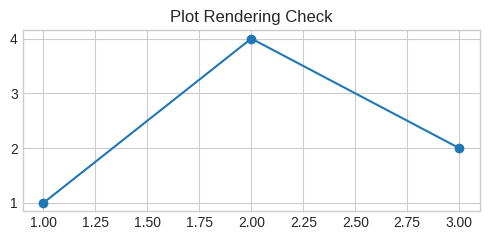

In [40]:
# Quick plot sanity check
fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot([1, 2, 3], [1, 4, 2], marker='o')
ax.set_title('Plot Rendering Check')
plt.tight_layout()
plt.show()

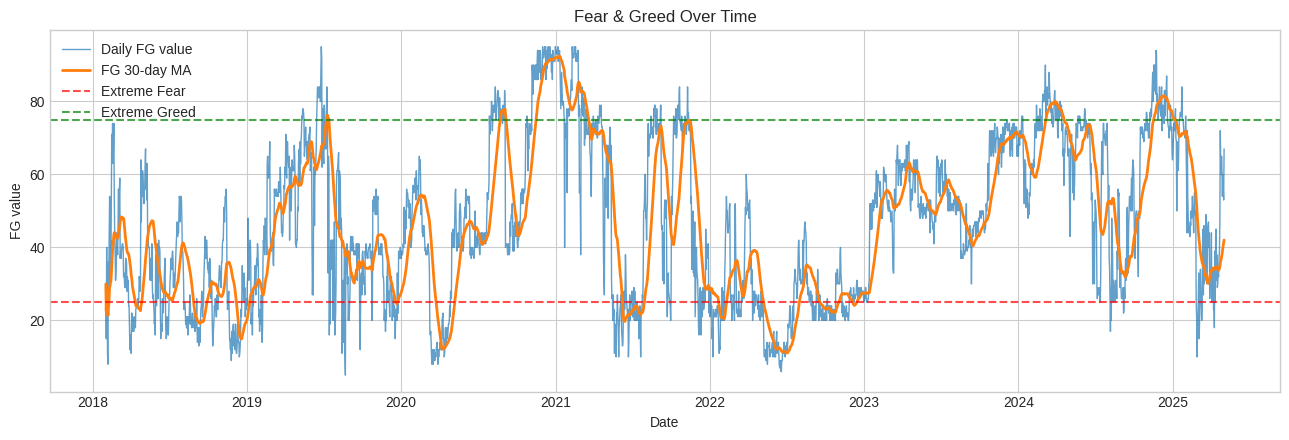

In [41]:
# 1) Fear & Greed trend
plot_fg = fg_clean.sort_values('fg_date').copy()
plot_fg['fg_30d_ma'] = plot_fg['fg_value'].rolling(30, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(plot_fg['fg_date'], plot_fg['fg_value'], label='Daily FG value', linewidth=1, alpha=0.7)
ax.plot(plot_fg['fg_date'], plot_fg['fg_30d_ma'], label='FG 30-day MA', linewidth=2)
ax.axhline(25, color='red', linestyle='--', alpha=0.7, label='Extreme Fear')
ax.axhline(75, color='green', linestyle='--', alpha=0.7, label='Extreme Greed')
ax.set_title('Fear & Greed Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('FG value')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

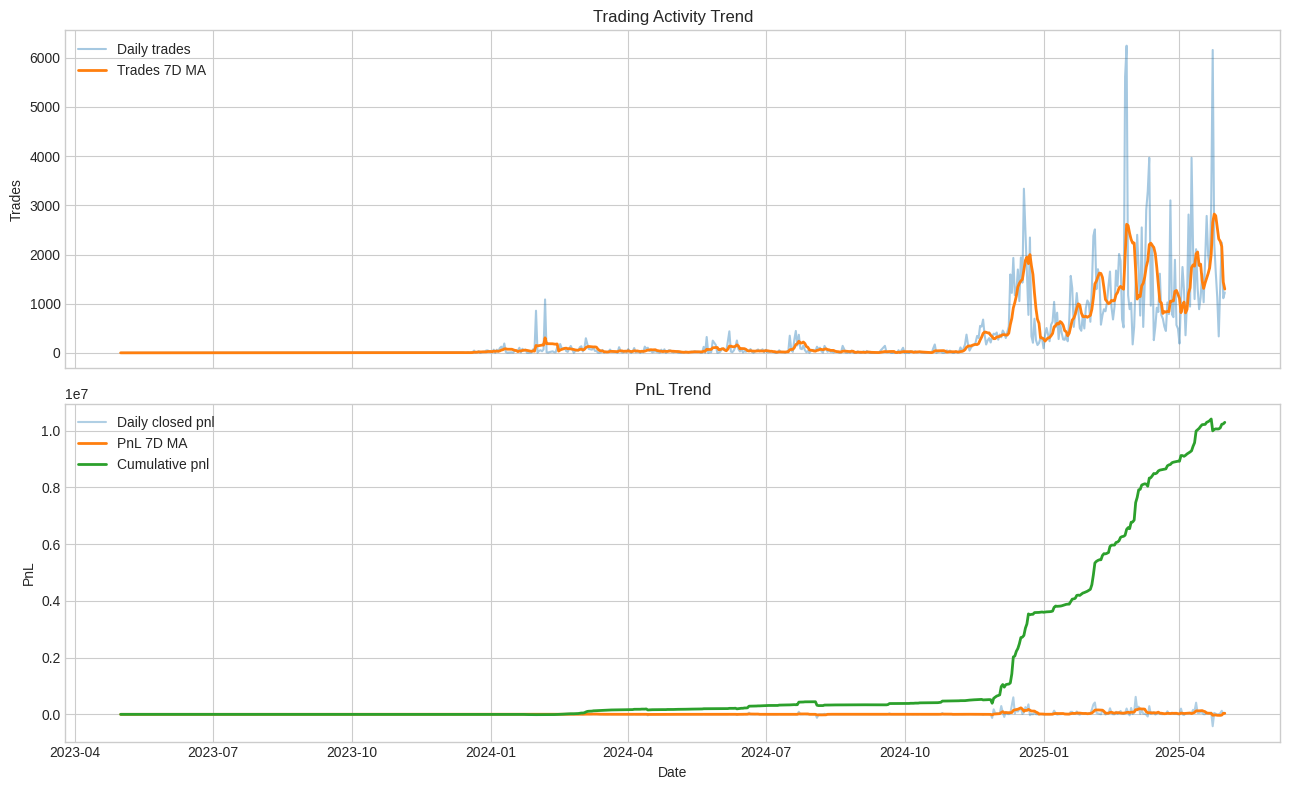

In [42]:
# 2) Daily trades and pnl trend
plot_daily = daily_metrics.sort_values('trade_date').copy()
plot_daily['trades_7d'] = plot_daily['trades'].rolling(7, min_periods=1).mean()
plot_daily['pnl_7d'] = plot_daily['total_closed_pnl'].rolling(7, min_periods=1).mean()
plot_daily['cum_pnl'] = plot_daily['total_closed_pnl'].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(plot_daily['trade_date'], plot_daily['trades'], alpha=0.4, label='Daily trades')
axes[0].plot(plot_daily['trade_date'], plot_daily['trades_7d'], linewidth=2, label='Trades 7D MA')
axes[0].set_title('Trading Activity Trend')
axes[0].set_ylabel('Trades')
axes[0].legend()

axes[1].plot(plot_daily['trade_date'], plot_daily['total_closed_pnl'], alpha=0.35, label='Daily closed pnl')
axes[1].plot(plot_daily['trade_date'], plot_daily['pnl_7d'], linewidth=2, label='PnL 7D MA')
axes[1].plot(plot_daily['trade_date'], plot_daily['cum_pnl'], linewidth=2, label='Cumulative pnl')
axes[1].set_title('PnL Trend')
axes[1].set_ylabel('PnL')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

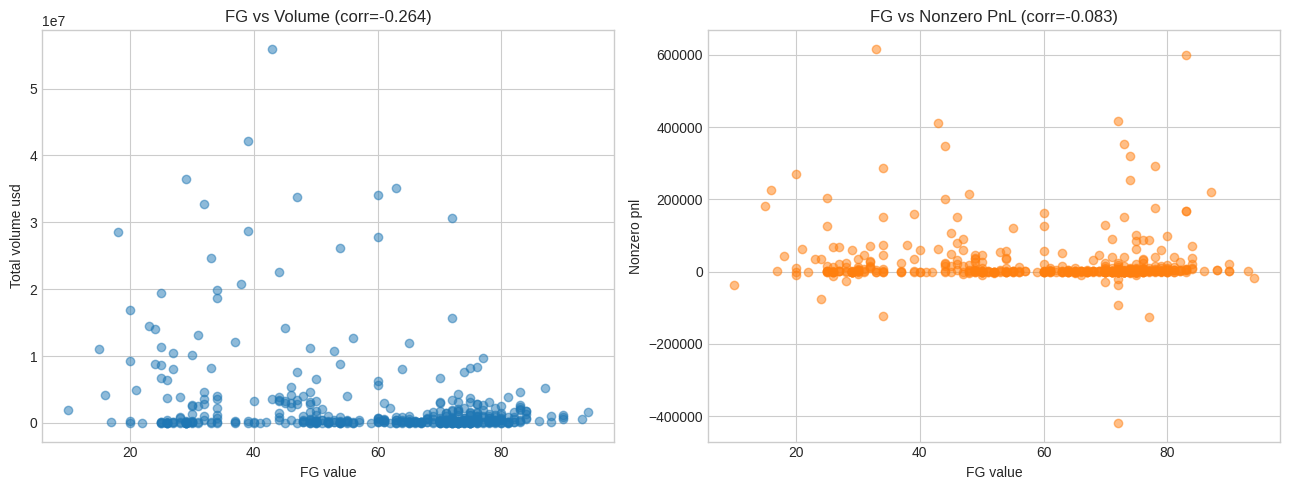

In [43]:
# 3) Correlation scatter: sentiment vs outcomes
corr_df = daily_metrics.dropna(subset=['fg_value']).copy()
vol_corr = corr_df['fg_value'].corr(corr_df['total_volume_usd'])
pnl_corr = corr_df['fg_value'].corr(corr_df['nonzero_closed_pnl'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(corr_df['fg_value'], corr_df['total_volume_usd'], alpha=0.5)
axes[0].set_title(f'FG vs Volume (corr={vol_corr:.3f})')
axes[0].set_xlabel('FG value')
axes[0].set_ylabel('Total volume usd')

axes[1].scatter(corr_df['fg_value'], corr_df['nonzero_closed_pnl'], alpha=0.5, color='tab:orange')
axes[1].set_title(f'FG vs Nonzero PnL (corr={pnl_corr:.3f})')
axes[1].set_xlabel('FG value')
axes[1].set_ylabel('Nonzero pnl')

plt.tight_layout()
plt.show()

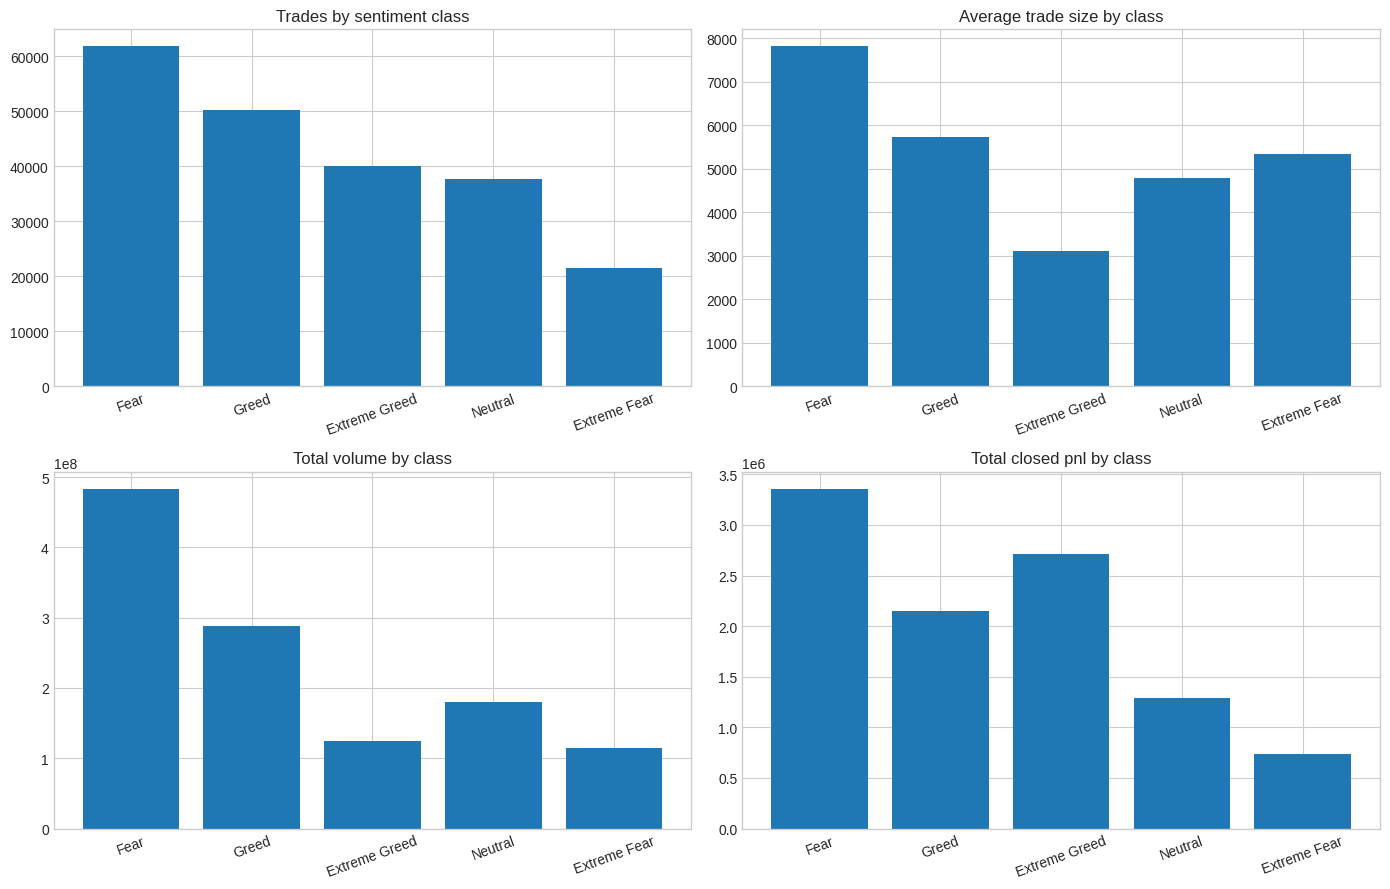

In [44]:
# 4) Sentiment class bar comparisons
c = class_summary.sort_values('trades', ascending=False).copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].bar(c['fg_classification'], c['trades'])
axes[0, 0].set_title('Trades by sentiment class')
axes[0, 0].tick_params(axis='x', rotation=20)

axes[0, 1].bar(c['fg_classification'], c['avg_trade_usd'])
axes[0, 1].set_title('Average trade size by class')
axes[0, 1].tick_params(axis='x', rotation=20)

axes[1, 0].bar(c['fg_classification'], c['total_volume_usd'])
axes[1, 0].set_title('Total volume by class')
axes[1, 0].tick_params(axis='x', rotation=20)

axes[1, 1].bar(c['fg_classification'], c['total_closed_pnl'])
axes[1, 1].set_title('Total closed pnl by class')
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

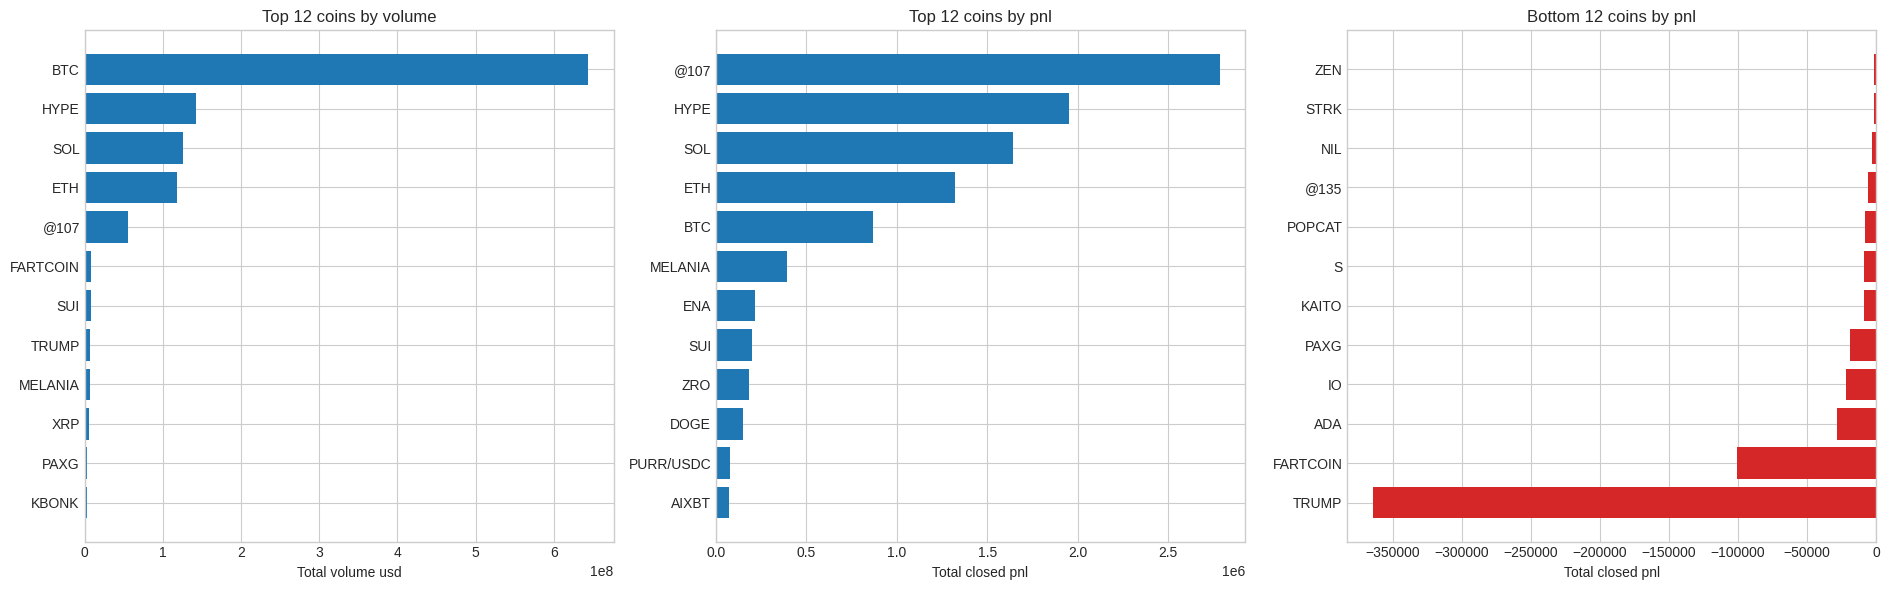

In [45]:
# 5) Coin patterns
top_vol = coin_summary.sort_values('total_volume_usd', ascending=False).head(12).sort_values('total_volume_usd')
top_pnl = coin_summary.sort_values('total_closed_pnl', ascending=False).head(12).sort_values('total_closed_pnl')
worst_pnl = coin_summary.sort_values('total_closed_pnl', ascending=True).head(12).sort_values('total_closed_pnl')

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

axes[0].barh(top_vol['coin'], top_vol['total_volume_usd'])
axes[0].set_title('Top 12 coins by volume')
axes[0].set_xlabel('Total volume usd')

axes[1].barh(top_pnl['coin'], top_pnl['total_closed_pnl'])
axes[1].set_title('Top 12 coins by pnl')
axes[1].set_xlabel('Total closed pnl')

axes[2].barh(worst_pnl['coin'], worst_pnl['total_closed_pnl'], color='tab:red')
axes[2].set_title('Bottom 12 coins by pnl')
axes[2].set_xlabel('Total closed pnl')

plt.tight_layout()
plt.show()

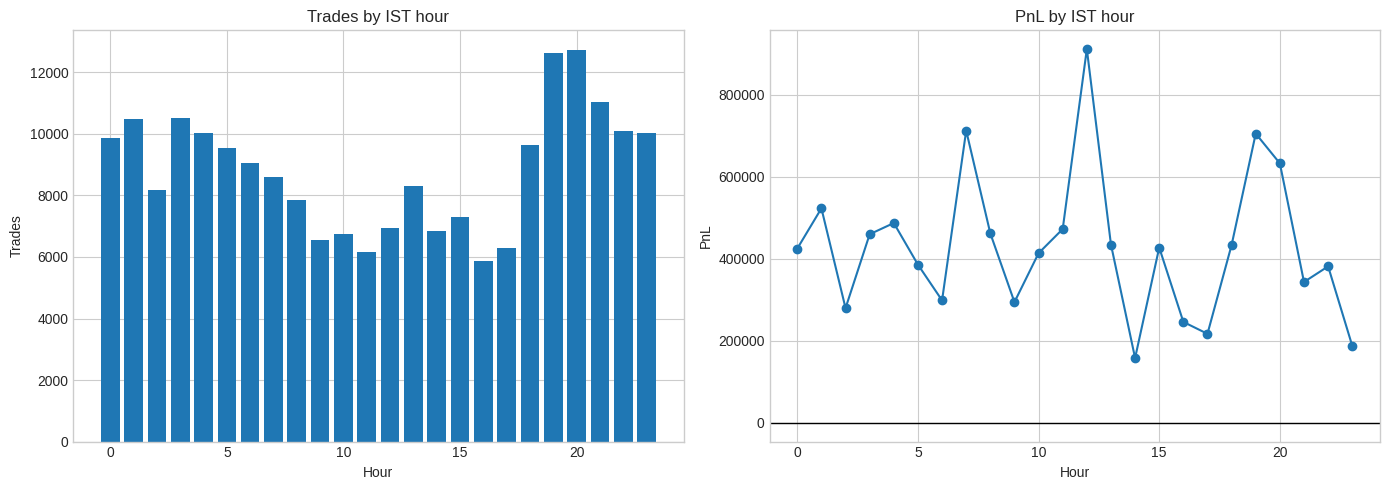

In [46]:
# 6) Intraday pattern (IST hour)
hourly = (
    hist_clean.assign(hour=hist_clean['timestamp_ist'].dt.hour)
    .groupby('hour', as_index=False)
    .agg(
        trades=('account', 'size'),
        volume=('size_usd', 'sum'),
        pnl=('closed_pnl', 'sum'),
    )
    .sort_values('hour')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hourly['hour'], hourly['trades'])
axes[0].set_title('Trades by IST hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Trades')

axes[1].plot(hourly['hour'], hourly['pnl'], marker='o')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('PnL by IST hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('PnL')

plt.tight_layout()
plt.show()

## Part C - Actionable Output


In [47]:
# Strategy rules of thumb based on findings
strategies = []

if pd.notna(fear_pnl) and pd.notna(greed_pnl):
    if fear_pnl > greed_pnl:
        strategies.append('During Fear days, keep normal sizing for profitable segments; tighten risk on Greed days.')
    else:
        strategies.append('During Greed days, keep normal sizing for profitable segments; tighten risk on Fear days.')

seg_summary = (
    trader_features.groupby('segment_consistency', as_index=False)
    .agg(mean_total_pnl=('total_pnl', 'mean'), mean_win_rate=('win_rate', 'mean'))
    .sort_values('mean_total_pnl', ascending=False)
)

best_seg = seg_summary.iloc[0]['segment_consistency'] if len(seg_summary) else 'ConsistentWinner'
worst_seg = seg_summary.iloc[-1]['segment_consistency'] if len(seg_summary) else 'Inconsistent'

strategies.append(f'Allocate more risk budget to {best_seg} profile and cap position size for {worst_seg} profile.')
strategies.append('For low win-rate high-frequency traders, enforce max trades/day and smaller position size until recovery.')

print('Recommended strategies')
for i, s in enumerate(strategies, 1):
    print(f'{i}. {s}')

display(seg_summary)

Recommended strategies
1. During Fear days, keep normal sizing for profitable segments; tighten risk on Greed days.
2. Allocate more risk budget to ConsistentWinner profile and cap position size for Inconsistent profile.
3. For low win-rate high-frequency traders, enforce max trades/day and smaller position size until recovery.


,segment_consistency,mean_total_pnl,mean_win_rate
0,ConsistentWinner,364352.408949,0.865002
1,Inconsistent,-89753.638695,0.706246


In [48]:
# Save summary markdown for submission
summary_lines = []
summary_lines.append('# Trader Behavior Insights Summary')
summary_lines.append('')
summary_lines.append('## Methodology')
summary_lines.append('- Cleaned and standardized sentiment + historical trade data.')
summary_lines.append('- Aligned by date and engineered daily trader behavior/performance metrics.')
summary_lines.append('- Compared Fear vs Greed outcomes and segmented traders.')
summary_lines.append('')
summary_lines.append('## Key Insights')
summary_lines.append(f'- Fear mean daily pnl: {float(fear_pnl):.2f}')
summary_lines.append(f'- Greed mean daily pnl: {float(greed_pnl):.2f}')
summary_lines.append(f'- Fear mean win rate: {float(fear_wr):.4f}')
summary_lines.append(f'- Greed mean win rate: {float(greed_wr):.4f}')
summary_lines.append('')
summary_lines.append('## Strategy Recommendations')
for i, s in enumerate(strategies, 1):
    summary_lines.append(f'{i}. {s}')

summary_text = '\n'.join(summary_lines)
Path('results_summary.md').write_text(summary_text, encoding='utf-8')
print('Saved results_summary.md')

Saved results_summary.md


## Part D - Advanced Evaluation

This section adds: significance tests, out-of-sample validation, segment risk metrics, and a predictive baseline.


In [49]:
# D1) Statistical significance tests: Fear vs Greed
fg_compare = account_daily[account_daily['sentiment_bucket'].isin(['Fear', 'Greed'])].copy()

fear_df = fg_compare[fg_compare['sentiment_bucket'] == 'Fear']
greed_df = fg_compare[fg_compare['sentiment_bucket'] == 'Greed']


def permutation_test_mean_diff(x, y, n_perm=3000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan

    observed = np.mean(x) - np.mean(y)
    pooled = np.concatenate([x, y])
    nx = len(x)

    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(pooled)
        diff = np.mean(perm[:nx]) - np.mean(perm[nx:])
        if abs(diff) >= abs(observed):
            count += 1

    p_value = (count + 1) / (n_perm + 1)
    return observed, p_value


def bootstrap_ci_mean_diff(x, y, n_boot=3000, seed=42, alpha=0.05):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan, np.nan

    diffs = np.empty(n_boot)
    for i in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        diffs[i] = np.mean(xb) - np.mean(yb)

    lo = float(np.quantile(diffs, alpha / 2))
    hi = float(np.quantile(diffs, 1 - alpha / 2))
    return lo, hi


def cohens_d(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) < 2 or len(y) < 2:
        return np.nan

    nx, ny = len(x), len(y)
    sx2, sy2 = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled_std = np.sqrt(((nx - 1) * sx2 + (ny - 1) * sy2) / (nx + ny - 2))
    if pooled_std == 0:
        return np.nan
    return (np.mean(x) - np.mean(y)) / pooled_std


metrics = {
    'total_pnl': 'Daily PnL',
    'win_rate': 'Win Rate',
    'trades': 'Trades per Trader-Day',
    'avg_trade_size_usd': 'Average Trade Size USD',
}

sig_rows = []
for col, label in metrics.items():
    x = fear_df[col].dropna().values
    y = greed_df[col].dropna().values
    if len(x) == 0 or len(y) == 0:
        continue

    obs_diff, p_val = permutation_test_mean_diff(x, y, n_perm=3000, seed=42)
    ci_lo, ci_hi = bootstrap_ci_mean_diff(x, y, n_boot=3000, seed=42)
    d = cohens_d(x, y)

    sig_rows.append({
        'metric': label,
        'fear_mean': float(np.mean(x)),
        'greed_mean': float(np.mean(y)),
        'mean_diff_fear_minus_greed': float(obs_diff),
        'perm_p_value': float(p_val),
        'bootstrap_ci_low': float(ci_lo),
        'bootstrap_ci_high': float(ci_hi),
        'cohens_d': float(d) if pd.notna(d) else np.nan,
        'significant_5pct': bool(p_val < 0.05),
    })

sig_results = pd.DataFrame(sig_rows).sort_values('perm_p_value')
print('Fear vs Greed significance tests (permutation p-values + bootstrap CI):')
display(sig_results)

Fear vs Greed significance tests (permutation p-values + bootstrap CI):


,metric,fear_mean,greed_mean,mean_diff_fear_minus_greed,perm_p_value,bootstrap_ci_low,bootstrap_ci_high,cohens_d,significant_5pct
2,Trades per Trader-Day,105.363291,76.912266,28.451025,0.001666,9.298134,47.684675,0.142608,True
3,Average Trade Size USD,8529.859802,5954.632633,2575.227170,0.002666,609.384643,5473.187814,0.113995,True
1,Win Rate,0.842294,0.856307,-0.014013,0.378540,-0.045552,0.015722,-0.048398,False
0,Daily PnL,5185.146443,4144.208334,1040.938110,0.477174,-1525.072057,3948.415531,0.034628,False


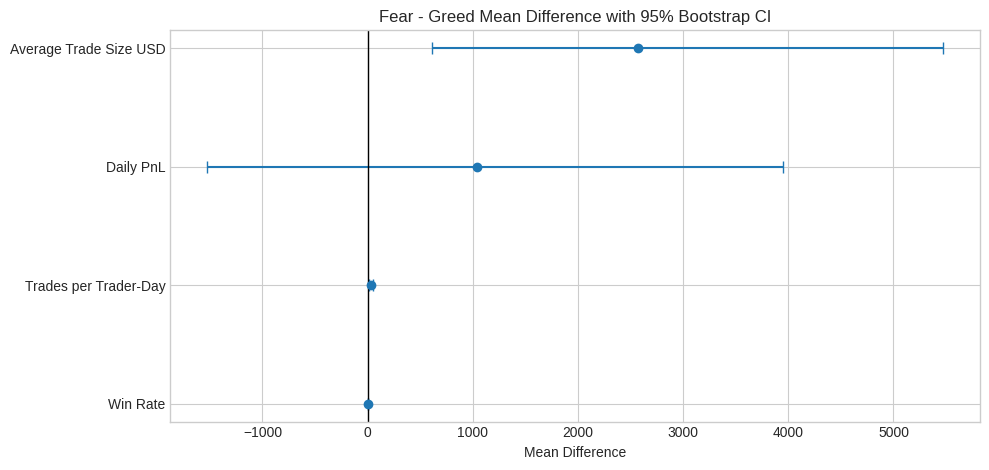

In [50]:
# D1) Visualization for significance test effect sizes
if len(sig_results) > 0:
    vis = sig_results.copy()
    vis = vis.sort_values('mean_diff_fear_minus_greed')

    err_left = vis['mean_diff_fear_minus_greed'] - vis['bootstrap_ci_low']
    err_right = vis['bootstrap_ci_high'] - vis['mean_diff_fear_minus_greed']

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.errorbar(
        vis['mean_diff_fear_minus_greed'],
        vis['metric'],
        xerr=[err_left.values, err_right.values],
        fmt='o',
        capsize=4,
    )
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title('Fear - Greed Mean Difference with 95% Bootstrap CI')
    ax.set_xlabel('Mean Difference')
    plt.tight_layout()
    plt.show()
else:
    print('No significance results to plot.')

Time split date: 2024-12-03
Chosen regime from train: Greed
Selected accounts from train: 15


,strategy,days,total_pnl,mean_daily_pnl,std_daily_pnl,sharpe_like,max_drawdown,total_pnl_vs_baseline_pct
0,Baseline (all test trades),123,8.405401e+06,68336.596352,125269.267447,8.659824,-419020.225731,0.000000
1,Regime-only (Greed),123,4.221939e+06,34324.711002,100133.491780,5.441615,-419020.225731,-49.771114
2,Selected accounts only (train consistent winners),123,2.961431e+06,24076.673469,60768.073246,6.289575,-102911.935621,-64.767526


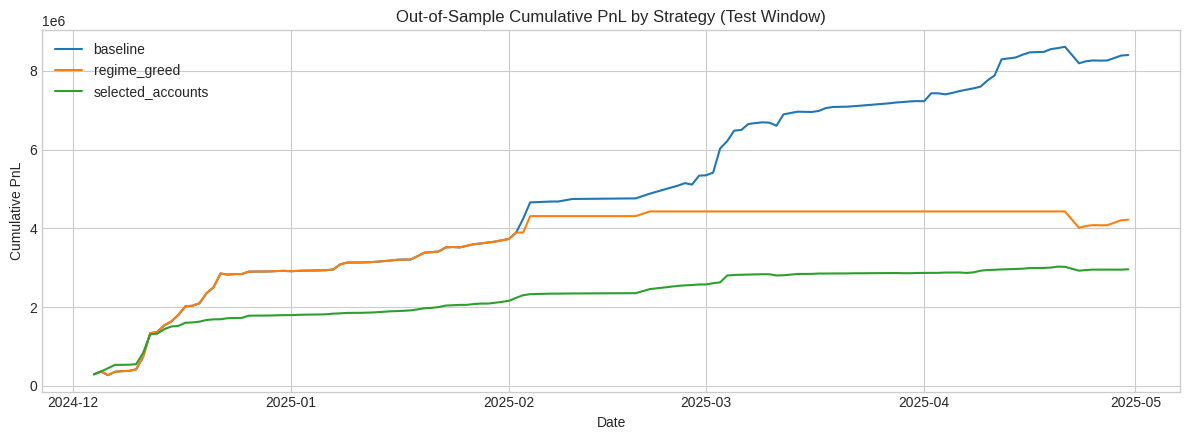

In [51]:
# D2) Out-of-sample validation for strategy rules (time split)


def max_drawdown_from_pnl(pnl_series):
    pnl = np.asarray(pnl_series, dtype=float)
    if len(pnl) == 0:
        return np.nan
    equity = np.cumsum(pnl)
    peak = np.maximum.accumulate(equity)
    dd = equity - peak
    return float(np.min(dd))


def strategy_stats(pnl_series):
    pnl = np.asarray(pnl_series, dtype=float)
    if len(pnl) == 0:
        return {
            'days': 0,
            'total_pnl': np.nan,
            'mean_daily_pnl': np.nan,
            'std_daily_pnl': np.nan,
            'sharpe_like': np.nan,
            'max_drawdown': np.nan,
        }
    std = np.std(pnl, ddof=1) if len(pnl) > 1 else 0.0
    sharpe_like = (np.mean(pnl) / std) * np.sqrt(252) if std > 0 else np.nan
    return {
        'days': int(len(pnl)),
        'total_pnl': float(np.sum(pnl)),
        'mean_daily_pnl': float(np.mean(pnl)),
        'std_daily_pnl': float(std),
        'sharpe_like': float(sharpe_like) if pd.notna(sharpe_like) else np.nan,
        'max_drawdown': max_drawdown_from_pnl(pnl),
    }


valid_df = account_daily[account_daily['sentiment_bucket'].isin(['Fear', 'Greed'])].copy()
all_dates = np.array(sorted(valid_df['trade_date'].dropna().unique()))

if len(all_dates) < 20:
    print('Not enough dates for robust out-of-sample validation.')
else:
    split_idx = int(len(all_dates) * 0.7)
    split_idx = min(max(split_idx, 1), len(all_dates) - 1)
    split_date = all_dates[split_idx]

    train = valid_df[valid_df['trade_date'] <= split_date].copy()
    test = valid_df[valid_df['trade_date'] > split_date].copy()

    # Rule 1: Select sentiment regime with better mean daily pnl in train.
    train_regime_perf = train.groupby('sentiment_bucket', as_index=False)['total_pnl'].mean()
    chosen_regime = train_regime_perf.sort_values('total_pnl', ascending=False).iloc[0]['sentiment_bucket']

    test_dates = np.array(sorted(test['trade_date'].unique()))

    baseline_daily = test.groupby('trade_date')['total_pnl'].sum().reindex(test_dates, fill_value=0.0)
    regime_daily = (
        test[test['sentiment_bucket'] == chosen_regime]
        .groupby('trade_date')['total_pnl']
        .sum()
        .reindex(test_dates, fill_value=0.0)
    )

    # Rule 2: Select train-time consistent winners and trade only those accounts on test.
    train_accounts = (
        train.groupby('account', as_index=False)
        .agg(total_pnl=('total_pnl', 'sum'), wins=('wins', 'sum'), pnl_nonzero=('pnl_nonzero_count', 'sum'))
    )
    train_accounts['win_rate'] = np.where(
        train_accounts['pnl_nonzero'] > 0,
        train_accounts['wins'] / train_accounts['pnl_nonzero'],
        np.nan,
    )
    selected_accounts = set(
        train_accounts[(train_accounts['win_rate'] >= 0.55) & (train_accounts['total_pnl'] > 0)]['account']
    )

    segment_daily = (
        test[test['account'].isin(selected_accounts)]
        .groupby('trade_date')['total_pnl']
        .sum()
        .reindex(test_dates, fill_value=0.0)
    )

    val_rows = []
    for name, series in [
        ('Baseline (all test trades)', baseline_daily.values),
        (f'Regime-only ({chosen_regime})', regime_daily.values),
        ('Selected accounts only (train consistent winners)', segment_daily.values),
    ]:
        row = {'strategy': name}
        row.update(strategy_stats(series))
        val_rows.append(row)

    oos_results = pd.DataFrame(val_rows)
    baseline_total = oos_results.loc[oos_results['strategy'] == 'Baseline (all test trades)', 'total_pnl'].iloc[0]
    oos_results['total_pnl_vs_baseline_pct'] = (oos_results['total_pnl'] - baseline_total) / abs(baseline_total) * 100

    print(f'Time split date: {pd.to_datetime(split_date).date()}')
    print(f'Chosen regime from train: {chosen_regime}')
    print(f'Selected accounts from train: {len(selected_accounts)}')
    display(oos_results)

    # Plot cumulative pnl on test for quick comparison.
    cum_plot = pd.DataFrame({
        'trade_date': test_dates,
        'baseline': np.cumsum(baseline_daily.values),
        f'regime_{chosen_regime.lower()}': np.cumsum(regime_daily.values),
        'selected_accounts': np.cumsum(segment_daily.values),
    })

    fig, ax = plt.subplots(figsize=(12, 4.5))
    for col in ['baseline', f'regime_{chosen_regime.lower()}', 'selected_accounts']:
        ax.plot(cum_plot['trade_date'], cum_plot[col], label=col)
    ax.set_title('Out-of-Sample Cumulative PnL by Strategy (Test Window)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative PnL')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [52]:
# D3) Risk metrics by trader segment (drawdown + tail risk)


def tail_risk_metrics(pnl_series):
    pnl = np.asarray(pnl_series, dtype=float)
    pnl = pnl[~np.isnan(pnl)]
    if len(pnl) == 0:
        return {
            'days': 0,
            'mean_daily_pnl': np.nan,
            'std_daily_pnl': np.nan,
            'var_95': np.nan,
            'cvar_95': np.nan,
            'max_drawdown': np.nan,
            'worst_day': np.nan,
            'best_day': np.nan,
        }

    var95 = np.quantile(pnl, 0.05)
    cvar95 = pnl[pnl <= var95].mean() if np.any(pnl <= var95) else var95
    std = np.std(pnl, ddof=1) if len(pnl) > 1 else 0.0

    return {
        'days': int(len(pnl)),
        'mean_daily_pnl': float(np.mean(pnl)),
        'std_daily_pnl': float(std),
        'var_95': float(var95),
        'cvar_95': float(cvar95),
        'max_drawdown': max_drawdown_from_pnl(pnl),
        'worst_day': float(np.min(pnl)),
        'best_day': float(np.max(pnl)),
    }


seg_daily = account_daily.merge(
    trader_features[['account', 'segment_frequency', 'segment_size', 'segment_consistency']],
    on='account',
    how='left',
)

risk_tables = {}
for seg_col in ['segment_consistency', 'segment_frequency', 'segment_size']:
    rows = []
    for seg_value, grp in seg_daily.groupby(seg_col):
        daily_pnl = grp.groupby('trade_date')['total_pnl'].sum().values
        metrics = tail_risk_metrics(daily_pnl)
        metrics[seg_col] = seg_value
        rows.append(metrics)

    tbl = pd.DataFrame(rows)
    first_col = [seg_col]
    other_cols = [c for c in tbl.columns if c != seg_col]
    tbl = tbl[first_col + other_cols].sort_values('mean_daily_pnl', ascending=False)
    risk_tables[seg_col] = tbl

print('Risk summary by segment_consistency')
display(risk_tables['segment_consistency'])

print('Risk summary by segment_frequency')
display(risk_tables['segment_frequency'])

print('Risk summary by segment_size')
display(risk_tables['segment_size'])

Risk summary by segment_consistency


,segment_consistency,days,mean_daily_pnl,std_daily_pnl,var_95,cvar_95,max_drawdown,worst_day,best_day
0,ConsistentWinner,476,22108.714003,68652.822168,-1619.198263,-25991.072919,-137369.608718,-127075.399585,616413.032233
1,Inconsistent,126,-2136.991397,42622.962754,-3926.842476,-83295.594915,-487073.059195,-467140.058684,35346.871080


Risk summary by segment_frequency


,segment_frequency,days,mean_daily_pnl,std_daily_pnl,var_95,cvar_95,max_drawdown,worst_day,best_day
0,Frequent,278,22092.278385,66256.035691,-3637.852938,-45237.830900,-240342.721197,-175221.823824,540091.961658
1,Infrequent,452,9099.189288,40768.997662,-1700.883799,-31937.825842,-345435.364976,-333314.457576,462195.085047


Risk summary by segment_size


,segment_size,days,mean_daily_pnl,std_daily_pnl,var_95,cvar_95,max_drawdown,worst_day,best_day
0,HighSize,440,15156.580602,59314.197455,-1942.677476,-32444.423451,-158470.988888,-127240.932229,593207.696073
1,LowSize,320,11204.973390,41314.416145,-2121.321717,-34658.163537,-343783.993034,-339910.788920,297733.865318


In [53]:
# D4) Lightweight predictive baseline: next-day profitability bucket
model_df = daily_metrics.sort_values('trade_date').copy()

# Target: is next day total closed pnl positive?
model_df['target_next_day_positive'] = (model_df['total_closed_pnl'].shift(-1) > 0).astype(int)

# Features available at day t to predict day t+1
feature_cols = ['fg_value', 'trades', 'total_volume_usd', 'buy_ratio', 'nonzero_closed_pnl', 'total_closed_pnl']
for col in feature_cols:
    model_df[f'{col}_lag1'] = model_df[col].shift(1)

used_features = feature_cols + [f'{c}_lag1' for c in feature_cols]
model_df = model_df.dropna(subset=used_features + ['target_next_day_positive']).reset_index(drop=True)

if len(model_df) < 50:
    print('Not enough rows for predictive baseline.')
else:
    split_idx = int(len(model_df) * 0.7)
    split_idx = min(max(split_idx, 10), len(model_df) - 10)

    train_df = model_df.iloc[:split_idx].copy()
    test_df = model_df.iloc[split_idx:].copy()

    X_train = train_df[used_features].values
    y_train = train_df['target_next_day_positive'].values.astype(int)
    X_test = test_df[used_features].values
    y_test = test_df['target_next_day_positive'].values.astype(int)

    def compute_binary_metrics(y_true, y_pred, y_prob=None):
        y_true = np.asarray(y_true).astype(int)
        y_pred = np.asarray(y_pred).astype(int)

        tp = int(np.sum((y_true == 1) & (y_pred == 1)))
        tn = int(np.sum((y_true == 0) & (y_pred == 0)))
        fp = int(np.sum((y_true == 0) & (y_pred == 1)))
        fn = int(np.sum((y_true == 1) & (y_pred == 0)))

        accuracy = (tp + tn) / len(y_true) if len(y_true) else np.nan
        precision = tp / (tp + fp) if (tp + fp) else np.nan
        recall = tp / (tp + fn) if (tp + fn) else np.nan
        f1 = 2 * precision * recall / (precision + recall) if pd.notna(precision) and pd.notna(recall) and (precision + recall) else np.nan

        roc_auc = np.nan
        if y_prob is not None:
            # Mann-Whitney-based AUC computation
            pos = y_prob[y_true == 1]
            neg = y_prob[y_true == 0]
            if len(pos) > 0 and len(neg) > 0:
                greater = 0
                ties = 0
                for p in pos:
                    greater += np.sum(p > neg)
                    ties += np.sum(p == neg)
                roc_auc = (greater + 0.5 * ties) / (len(pos) * len(neg))

        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'tp': tp,
            'tn': tn,
            'fp': fp,
            'fn': fn,
        }

    # Baseline model: majority class from train
    majority_class = int(np.round(np.mean(y_train) >= 0.5))
    y_pred_baseline = np.full_like(y_test, fill_value=majority_class)
    baseline_metrics = compute_binary_metrics(y_test, y_pred_baseline, None)

    # Logistic baseline (if scikit-learn available)
    sklearn_ok = True
    try:
        from sklearn.linear_model import LogisticRegression
        from sklearn.pipeline import Pipeline
        from sklearn.preprocessing import StandardScaler

        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(max_iter=1000, class_weight='balanced')),
        ])
        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:, 1]
        model_metrics = compute_binary_metrics(y_test, y_pred, y_prob)

        # Coefficients for interpretability
        coef = clf.named_steps['lr'].coef_[0]
        coef_df = pd.DataFrame({'feature': used_features, 'coef': coef}).sort_values('coef', ascending=False)
    except Exception as e:
        sklearn_ok = False
        model_metrics = None
        coef_df = None
        print('scikit-learn model unavailable, fallback to majority baseline only.')
        print('Reason:', e)

    rows = [
        {'model': 'Majority baseline', **baseline_metrics},
    ]
    if sklearn_ok and model_metrics is not None:
        rows.append({'model': 'Logistic regression baseline', **model_metrics})

    pred_results = pd.DataFrame(rows)
    print('Predictive baseline results (test window):')
    display(pred_results)

    if sklearn_ok and coef_df is not None:
        print('Top positive logistic coefficients:')
        display(coef_df.head(8))
        print('Top negative logistic coefficients:')
        display(coef_df.tail(8).sort_values('coef'))

        # Probability trend plot on test window
        pred_plot = pd.DataFrame({
            'trade_date': test_df['trade_date'].values,
            'y_true': y_test,
            'y_prob': y_prob,
        })

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(pred_plot['trade_date'], pred_plot['y_prob'], label='Predicted P(next day profitable)', linewidth=1.6)
        ax.scatter(pred_plot['trade_date'], pred_plot['y_true'], label='Actual class (0/1)', s=10, alpha=0.5)
        ax.set_title('Predictive Baseline - Test Window')
        ax.set_xlabel('Date')
        ax.set_ylabel('Probability / Class')
        ax.legend()
        plt.tight_layout()
        plt.show()

scikit-learn model unavailable, fallback to majority baseline only.
Reason: No module named 'sklearn'
Predictive baseline results (test window):


,model,accuracy,precision,recall,f1,roc_auc,tp,tn,fp,fn
0,Majority baseline,0.895833,0.895833,1.0,0.945055,NaN,129,0,15,0


### D5 - Clustering Traders into Behavioral Archetypes


sklearn unavailable, using fallback clustering: No module named 'sklearn'
Clustering method: fallback


,archetype,cluster_id,traders,mean_total_pnl,mean_win_rate,mean_trades_per_day,mean_trade_size
0,HighActivity_Winner,3,9,662459.834939,0.878011,223.855813,8735.811373
1,LowActivity_Winner,1,7,551513.500498,0.863828,36.076018,5949.701256
2,LowActivity_Winner,0,9,32745.672097,0.864691,30.179822,3144.408791
3,HighActivity_Winner,2,7,25644.982376,0.781811,151.950292,6240.549938


,account,archetype,total_trades,active_days,total_pnl,avg_trade_size_usd,avg_trades_per_day,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,HighActivity_Winner,3818,24,1.600230e+06,16159.576734,159.083333,0.792725
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,HighActivity_Winner,7280,52,4.788532e+04,1653.226327,140.000000,0.773644
2,0x271b280974205ca63b716753467d5a371de622ab,HighActivity_Winner,3809,12,-7.043619e+04,8893.000898,317.416667,0.715619
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,HighActivity_Winner,13311,162,1.324648e+05,507.626933,82.166667,0.862079
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,LowActivity_Winner,3239,69,1.686580e+05,3138.894782,46.942029,0.817476
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,LowActivity_Winner,815,43,-3.120360e+04,1729.941104,18.953488,0.650877
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,HighActivity_Winner,3589,46,1.445692e+04,4790.575486,78.021739,0.665535
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,LowActivity_Winner,332,28,5.349625e+04,3445.471265,11.857143,1.000000
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,LowActivity_Winner,383,20,1.995056e+05,5189.367128,19.150000,1.000000
9,0x430f09841d65beb3f27765503d0f850b8bce7713,LowActivity_Winner,1237,28,4.165419e+05,2397.824753,44.178571,1.000000


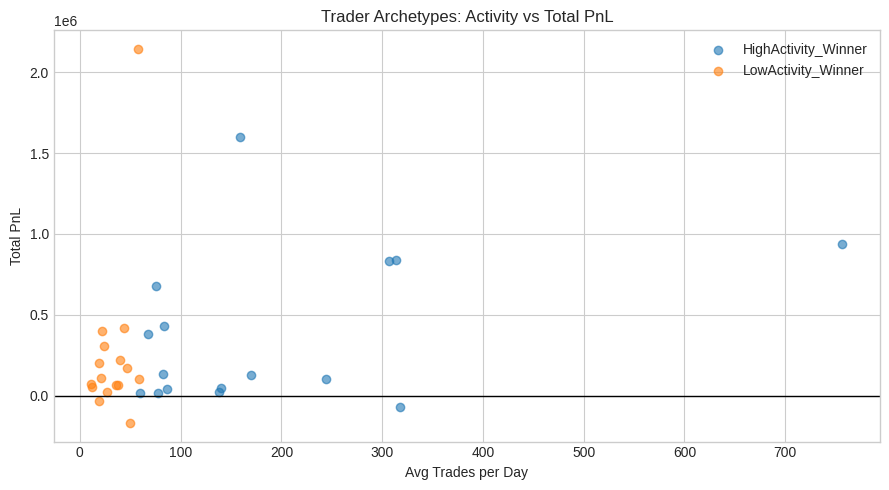

Saved trader_archetypes.csv and trader_archetype_summary.csv


In [54]:
# D5) Clustering traders into behavioral archetypes (extracted model module)
from modeling import cluster_traders

cluster_result = cluster_traders(trader_features, n_clusters=4)
if cluster_result.get('status') != 'ok':
    print(cluster_result.get('message', 'Unable to cluster traders.'))
else:
    cluster_df = cluster_result['cluster_df']
    archetype_summary = cluster_result['summary_df']
    print('Clustering method:', cluster_result['method'])
    display(archetype_summary[['archetype', 'cluster_id', 'traders', 'mean_total_pnl', 'mean_win_rate', 'mean_trades_per_day', 'mean_trade_size']])
    display(cluster_df[['account', 'archetype'] + cluster_result['features']].head(20))

    if 'avg_trades_per_day' in cluster_df.columns and 'total_pnl' in cluster_df.columns:
        fig, ax = plt.subplots(figsize=(9, 5))
        for arch, grp in cluster_df.groupby('archetype'):
            ax.scatter(grp['avg_trades_per_day'], grp['total_pnl'], alpha=0.6, label=arch)
        ax.axhline(0, color='black', linewidth=1)
        ax.set_title('Trader Archetypes: Activity vs Total PnL')
        ax.set_xlabel('Avg Trades per Day')
        ax.set_ylabel('Total PnL')
        ax.legend()
        plt.tight_layout()
        plt.show()

    cluster_df.to_csv('trader_archetypes.csv', index=False)
    archetype_summary.to_csv('trader_archetype_summary.csv', index=False)
    print('Saved trader_archetypes.csv and trader_archetype_summary.csv')

### D6 - Simple Predictive Models (Trader Next-Day Profitability and Volatility)


In [55]:
# D6) Predict next-day trader profitability bucket and volatility (extracted model module)
from modeling import run_trader_day_models

model_result = run_trader_day_models(account_daily, daily_metrics)
if model_result.get('status') != 'ok':
    print(model_result.get('message', 'Unable to run trader-day models.'))
else:
    cls_metrics_df = model_result['cls_metrics_df']
    reg_metrics_df = model_result['reg_metrics_df']

    print('Time split date:', pd.to_datetime(model_result['split_date']).date())
    print('Trader-level profitability bucket metrics')
    display(cls_metrics_df)
    print('Trader-level next-day volatility metrics')
    display(reg_metrics_df)

    if model_result.get('coef_cls_df') is not None:
        print('Top classification coefficients')
        display(model_result['coef_cls_df'].head(10))
    if model_result.get('coef_reg_df') is not None:
        print('Top volatility coefficients')
        display(model_result['coef_reg_df'].head(10))
    if model_result.get('sklearn_error'):
        print('scikit-learn note:', model_result['sklearn_error'])

    cls_metrics_df.to_csv('trader_profitability_model_metrics.csv', index=False)
    reg_metrics_df.to_csv('trader_volatility_model_metrics.csv', index=False)
    print('Saved trader_profitability_model_metrics.csv and trader_volatility_model_metrics.csv')

scikit-learn unavailable for advanced models: No module named 'sklearn'
Time split date: 2024-12-08
Trader-level profitability bucket metrics


,model,accuracy,precision,recall,f1
0,Majority baseline,0.658745,0.658745,1.0,0.794269


Trader-level next-day volatility metrics


,model,mae,rmse,r2_like
0,Mean baseline,8495.367407,31174.615764,-0.013917


Saved trader_profitability_model_metrics.csv and trader_volatility_model_metrics.csv


## Part E - Streamlit Dashboard

A lightweight interactive dashboard is included in `streamlit_app.py`.

Run it with:

```bash
streamlit run streamlit_app.py
```
